# Neural Network Model (Steam Dataset)
This notebook implements an MLP neural network using precomputed features.

In [8]:
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [9]:
RANDOM_STATE = 42

In [10]:
# Q1
X_meta_q1 = sparse.load_npz("../outputs/features/X_meta_q1.npz")
X_tfidf_q1 = sparse.load_npz("../outputs/features/X_tfidf_q1.npz")
y_q1 = np.load("../outputs/features/y_q1.npy")

train_idx_q1 = np.load("../outputs/features/train_idx_q1.npy")
test_idx_q1 = np.load("../outputs/features/test_idx_q1.npy")

# Q2
X_meta_q2 = sparse.load_npz("../outputs/features/X_meta_q2.npz")
X_tfidf_q2 = sparse.load_npz("../outputs/features/X_tfidf_q2.npz")
y_q2 = np.load("../outputs/features/y_q2.npy")

train_idx_q2 = np.load("../outputs/features/train_idx_q2.npy")
test_idx_q2 = np.load("../outputs/features/test_idx_q2.npy")

In [11]:
def train_and_eval(X_train, X_test, y_train, y_test):
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=100,
        early_stopping=True,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    return acc, macro, prec, rec, f1, cm

In [12]:
results = []

# ===== Q1 =====
configs_q1 = {
    "meta only": X_meta_q1,
    "text only": X_tfidf_q1,
    "meta + text": sparse.hstack([X_meta_q1, X_tfidf_q1])
}

cm_results = {}

for name, X in configs_q1.items():
    X_train = X[train_idx_q1]
    X_test = X[test_idx_q1]
    y_train = y_q1[train_idx_q1]
    y_test = y_q1[test_idx_q1]

    acc, macro, prec, rec, f1, cm = train_and_eval(X_train, X_test, y_train, y_test)

    results.append(["Q1", name, acc, macro, prec, rec, f1])
    cm_results[f"Q1_{name}"] = cm

# ===== Q2 =====
configs_q2 = {
    "meta only": X_meta_q2,
    "text only": X_tfidf_q2,
    "meta + text": sparse.hstack([X_meta_q2, X_tfidf_q2])
}

for name, X in configs_q2.items():
    X_train = X[train_idx_q2]
    X_test = X[test_idx_q2]
    y_train = y_q2[train_idx_q2]
    y_test = y_q2[test_idx_q2]

    acc, macro, prec, rec, f1, cm = train_and_eval(X_train, X_test, y_train, y_test)

    results.append(["Q2", name, acc, macro, prec, rec, f1])
    cm_results[f"Q2_{name}"] = cm

In [13]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Task", "Feature", "Accuracy", "Macro-F1", "Precision+", "Recall+", "F1+"]
)

results_df

,Task,Feature,Accuracy,Macro-F1,Precision+,Recall+,F1+
0,Q1,meta only,0.857431,0.744198,0.746245,0.466367,0.574007
1,Q1,text only,0.811881,0.583362,0.666918,0.173054,0.274802
2,Q1,meta + text,0.862948,0.757783,0.754993,0.495307,0.598182
3,Q2,meta only,0.680327,0.675071,0.701162,0.732307,0.716396
4,Q2,text only,0.636898,0.621039,0.644089,0.763103,0.698563
5,Q2,meta + text,0.705469,0.696323,0.706376,0.797157,0.749026


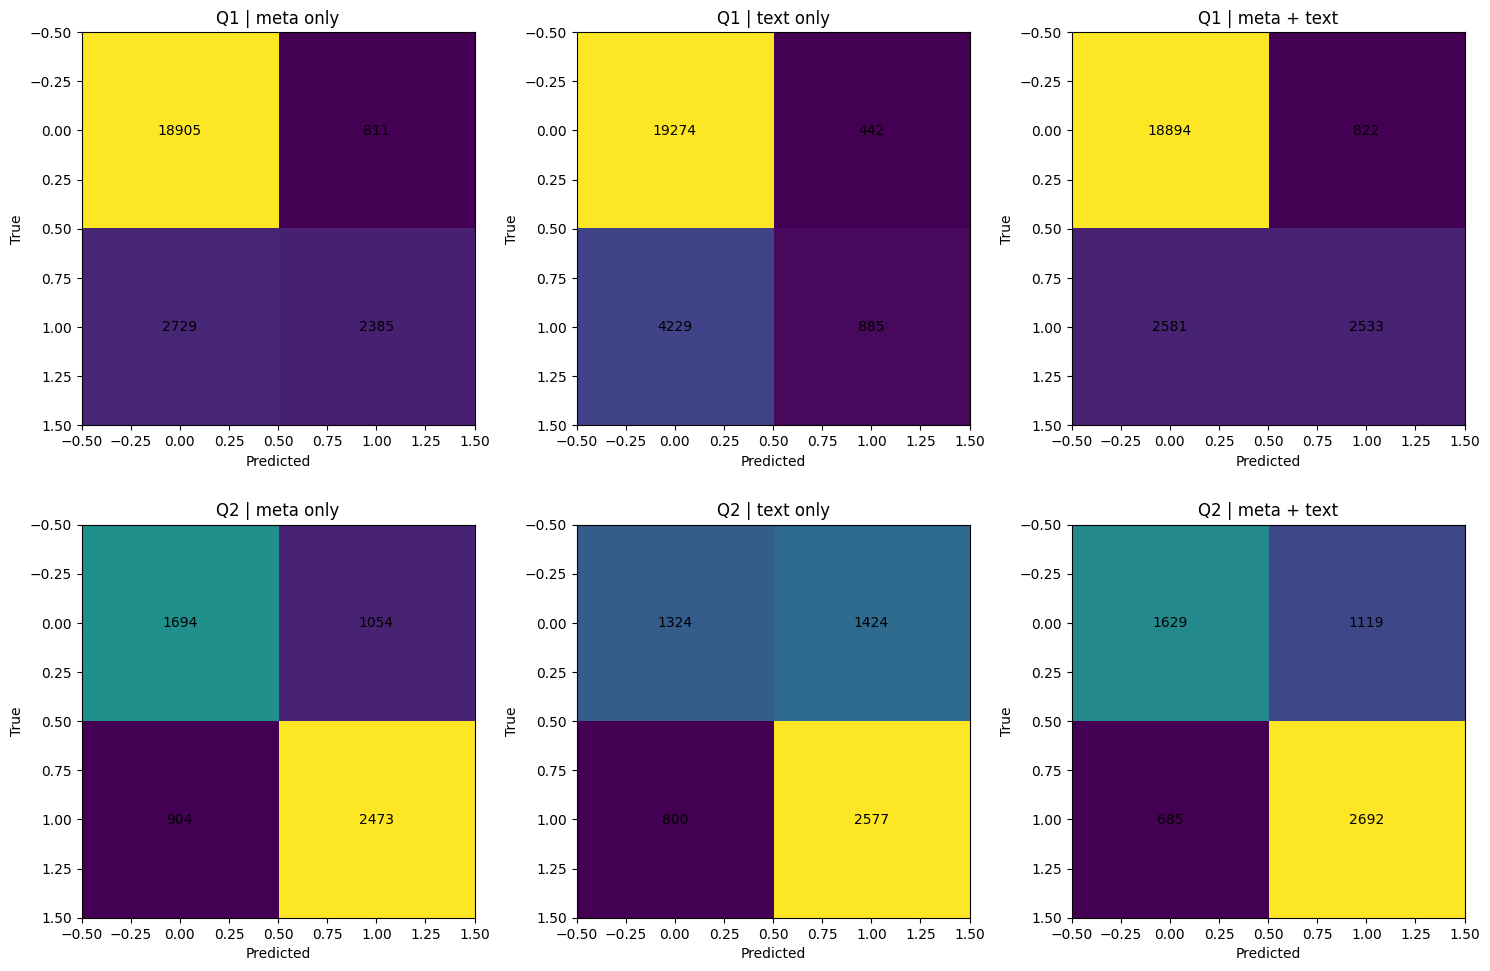

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

titles = ["meta only", "text only", "meta + text"]

# ===== Q1 (top row) =====
for i, name in enumerate(titles):
    cm = cm_results[f"Q1_{name}"]
    ax = axes[0, i]
    im = ax.imshow(cm)

    for (r, c), val in np.ndenumerate(cm):
        ax.text(c, r, val, ha='center', va='center')

    ax.set_title(f"Q1 | {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# ===== Q2 (bottom row) =====
for i, name in enumerate(titles):
    cm = cm_results[f"Q2_{name}"]
    ax = axes[1, i]
    im = ax.imshow(cm)

    for (r, c), val in np.ndenumerate(cm):
        ax.text(c, r, val, ha='center', va='center')

    ax.set_title(f"Q2 | {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

In [15]:
# =========================
# Second Neural Network (Deeper)
# =========================

from sklearn.neural_network import MLPClassifier

def train_and_eval_nn(X_train, X_test, y_train, y_test):
    model = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),  # 更深结构
        activation='relu',
        solver='adam',
        max_iter=30,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    macro = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)

    return acc, macro, prec, rec, f1, cm

In [17]:
# =========================
# Run Second NN for Q1 & Q2
# =========================

results_nn2 = []
cm_results_nn2 = {}

# Q1
X_train = X_q1[train_idx_q1]
X_test  = X_q1[test_idx_q1]
y_train = y_q1[train_idx_q1]
y_test  = y_q1[test_idx_q1]

acc, macro, prec, rec, f1, cm = train_and_eval_nn(X_train, X_test, y_train, y_test)
results_nn2.append(["Q1", "NN (256,128,64)", acc, macro, prec, rec, f1])
cm_results_nn2["Q1"] = cm


# Q2
X_train = X_q2[train_idx_q2]
X_test  = X_q2[test_idx_q2]
y_train = y_q2[train_idx_q2]
y_test  = y_q2[test_idx_q2]

acc, macro, prec, rec, f1, cm = train_and_eval_nn(X_train, X_test, y_train, y_test)
results_nn2.append(["Q2", "NN (256,128,64)", acc, macro, prec, rec, f1])
cm_results_nn2["Q2"] = cm

NameError: name 'X_q1' is not defined

In [ ]:
# =========================
# Merge results
# =========================

import pandas as pd

results_nn2_df = pd.DataFrame(
    results_nn2,
    columns=["Task", "Feature", "Accuracy", "Macro-F1", "Precision+", "Recall+", "F1+"]
)

# 假设你原来的结果是 results_df
final_results = pd.concat([results_df, results_nn2_df], ignore_index=True)

final_results

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

titles = ["Q1 - NN (old)", "Q1 - NN (new)", "Q2 - NN (old)", "Q2 - NN (new)"]

cms = [
    cm_results["Q1"],          # 你原来的
    cm_results_nn2["Q1"],      # 新的
    cm_results["Q2"],
    cm_results_nn2["Q2"]
]

for ax, cm, title in zip(axes.flatten(), cms, titles):
    im = ax.imshow(cm)
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()